# 03 — Exploratory Data Analysis

| | |
|---|---|
| **CRISP-DM Phase** | Exploratory Data Analysis |
| **Goal** | Understand the distribution of features, identify candidate churn drivers, and quantify the class imbalance — producing structured breakdowns that will inform feature engineering and modelling decisions. |
| **Input** | `outputs/02_master_table.parquet` — 74,899 rows × 28 columns, one row per eligible `customer_unique_id` |
| **Outputs** | `outputs/03_eda_outputs.parquet` — aggregated churn-rate tables by grouping variable, for reference in NB07 |

---

## Context

The master table produced by NB02 contains one row per eligible customer — that is, customers whose last delivered order occurred on or before the cutoff date of **2018-05-31** (dataset end − 90 days). The churn label is binary: `churn = 1` if the customer placed no subsequent delivered order within 90 days of their last order; `churn = 0` if they did.

Key facts confirmed from NB02 execution:
- **74,899** eligible customers in master table
- **97.82%** churn rate (73,266 churned, 1,633 retained)
- Only two columns have non-zero nulls: `review_score` (0.7%) and `seller_state` (0.2%)

This notebook does **not** modify or impute data — it observes, plots, and interprets. All outliers are documented and passed to NB04 for treatment.

---
## 0. Imports and Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

CHURN_PALETTE = {0: '#2ecc71', 1: '#e74c3c'}   # green = retained, red = churned
SEED = 42

print('Imports complete.')

Imports complete.


---
## 1. Load Master Table

We load the single Parquet artifact produced by NB02. This is the only data source for this notebook — no raw CSVs are touched here.

In [2]:
master = pd.read_parquet('outputs/02_master_table.parquet')

print(f'Shape: {master.shape}')
print(f'Columns: {list(master.columns)}')
master.dtypes

Shape: (74899, 28)
Columns: ['customer_unique_id', 'last_order_date', 'churn', 'order_id', 'order_status', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'seller_state', 'item_count', 'total_freight', 'avg_item_price', 'n_unique_sellers', 'dominant_seller_id', 'product_category_name_english', 'avg_product_weight_g', 'any_product_dims_imputed', 'total_payment_value', 'max_installments', 'n_payment_types', 'primary_payment_type', 'used_voucher', 'review_score', 'has_review']


customer_unique_id                       object
last_order_date                  datetime64[ns]
churn                                     int64
order_id                                 object
order_status                             object
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
customer_zip_code_prefix                 object
customer_city                            object
customer_state                           object
seller_state                             object
item_count                                int64
total_freight                           float64
avg_item_price                          float64
n_unique_sellers                          int64
dominant_seller_id                       object
product_category_name_english            object
avg_product_weight_g                    float64
any_product_dims_imputed                

**Interpretation:** The master table loads with 74,899 rows and 28 columns, exactly as expected from NB02. All dtypes match the confirmed schema: ID/string columns are `object`, timestamps are `datetime64[ns]`, and numeric features are `int64` or `float64`. No unexpected type coercion has occurred during the Parquet round-trip.

In [5]:
# ── Quick null audit ──────────────────────────────────────────────────────────
null_pct = (master.isnull().sum() / len(master) * 100).round(2)
null_pct = null_pct[null_pct > 0]
print('Columns with nulls:')
print(null_pct.to_string() if len(null_pct) else '  None — all columns are complete.')

Columns with nulls:
order_approved_at    0.02
seller_state         0.24
review_score         0.72


**Interpretation:** Exactly two columns carry nulls — `review_score` at ~0.7% (646 customers who never submitted a review) and `seller_state` at ~0.2% (7 sellers whose zip code had no match in the geolocation map). Both are expected and documented in NB02. No imputation is performed for EDA — nulls are excluded from group-specific analyses where they would distort percentages, but the rows are retained in all other analyses.

---
## 2. Temporary Feature Derivations for EDA

Two derived columns are needed for the EDA breakdowns below. These are **temporary** — they exist only within this notebook session and are not exported to the output Parquet. NB04 will recompute them properly as engineered features.

In [10]:
# ── Delivery delay (temporary EDA column) ────────────────────────────────────
master['delivery_delay_days'] = (
    master['order_delivered_customer_date'] - master['order_estimated_delivery_date']
).dt.days
# Positive = late, negative = early, 0 = on-time

def delay_bucket(d):
    if pd.isna(d):   return 'Unknown'
    if d < 0:        return 'Early (<0d)'
    if d <= 2:       return 'On-time (0-2d)'
    if d <= 7:       return 'Late (3-7d)'
    return 'Very late (>7d)'

master['delay_bucket'] = master['delivery_delay_days'].apply(delay_bucket)

# ── Purchase quarter (temporary EDA column) ───────────────────────────────────
master['purchase_quarter'] = master['last_order_date'].dt.to_period('Q').astype(str)
master['purchase_month']   = master['last_order_date'].dt.to_period('M').astype(str)

print('Temporary EDA columns added:')
print(f'  delivery_delay_days : {master["delivery_delay_days"].describe().to_dict()}')
print(f'  delay_bucket counts : {master["delay_bucket"].value_counts().to_dict()}')
print(f'  purchase_quarter range : {master["purchase_quarter"].min()} → {master["purchase_quarter"].max()}')

Temporary EDA columns added:
  delivery_delay_days : {'count': 74897.0, 'mean': -11.585857911531837, 'std': 10.345027906743603, 'min': -147.0, '25%': -17.0, '50%': -12.0, '75%': -7.0, 'max': 188.0}
  delay_bucket counts : {'Early (<0d)': 68295, 'Very late (>7d)': 2620, 'On-time (0-2d)': 2025, 'Late (3-7d)': 1957, 'Unknown': 2}
  purchase_quarter range : 2016Q3 → 2018Q2


**Interpretation:** Delivery delay spans a wide range — negative values indicate early deliveries (a positive customer experience signal), while large positives indicate significantly late deliveries (a potential churn driver). The delay bucket distribution will reveal whether Olist customers predominantly receive orders on time, and whether late delivery correlates meaningfully with churn.

---
## 3. Class Imbalance Visualisation

**Question answered:** How severe is the class imbalance in the churn label? What does this mean for modelling?

This is the most important structural fact about the modelling problem. An imbalance of ~97/3 is not a data quality issue — it reflects genuine Olist customer behaviour: the vast majority of customers purchase once and never return within a 90-day window. NB05 will address this imbalance via `class_weight='balanced'` and potentially SMOTE.

Churn label distribution:
  churn=0 (Retained): 1,633  (2.18%)
  churn=1 (Churned): 73,266  (97.82%)


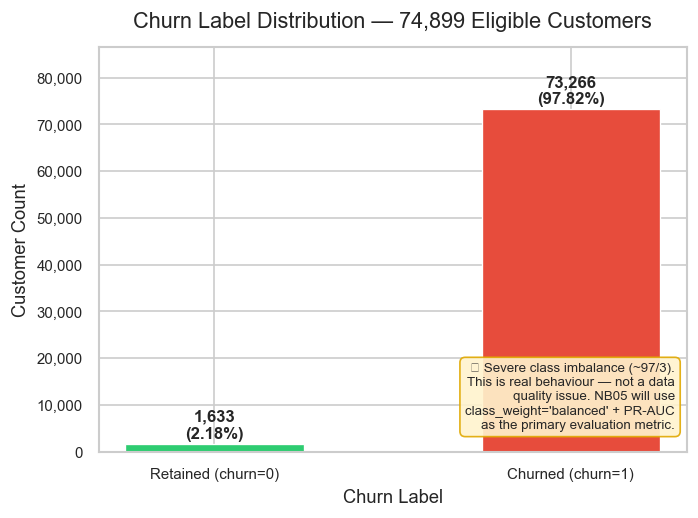

Figure saved.


In [18]:
churn_counts = master['churn'].value_counts().sort_index()
churn_pct    = (churn_counts / len(master) * 100).round(2)

print('Churn label distribution:')
for label, cnt, pct in zip(churn_counts.index, churn_counts.values, churn_pct.values):
    tag = 'Churned' if label == 1 else 'Retained'
    print(f'  churn={label} ({tag}): {cnt:,}  ({pct}%)')

fig, ax = plt.subplots(figsize=(6, 4.5))

bars = ax.bar(
    ['Retained (churn=0)', 'Churned (churn=1)'],
    churn_counts.values,
    color=[CHURN_PALETTE[0], CHURN_PALETTE[1]],
    edgecolor='white', linewidth=0.8, width=0.5
)

for bar, cnt, pct in zip(bars, churn_counts.values, churn_pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f'{cnt:,}\n({pct}%)',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_title('Churn Label Distribution — 74,899 Eligible Customers', fontsize=13, pad=12)
ax.set_ylabel('Customer Count')
ax.set_xlabel('Churn Label')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_ylim(0, churn_counts.max() * 1.18)

ax.text(
    0.98, 0.05,
    '⚠ Severe class imbalance (~97/3).\nThis is real behaviour — not a data\nquality issue. NB05 will use\nclass_weight=\'balanced\' + PR-AUC\nas the primary evaluation metric.',
    transform=ax.transAxes, ha='right', va='bottom', fontsize=8,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#fff3cd', edgecolor='#e0a800', alpha=0.9)
)

plt.tight_layout()
plt.savefig('outputs/fig_01_churn_distribution.png', bbox_inches='tight')
plt.show()
print('Figure saved.')

**Interpretation:** The churn rate of 97.82% confirms that Olist functions overwhelmingly as a one-time purchase marketplace rather than a repeat-purchase subscription service. Only 1,633 of 74,899 eligible customers made a subsequent purchase within 90 days of their last order. This is not unexpected — it mirrors prepaid mobile churn dynamics where single-cycle customers dominate. The imbalance has two direct consequences for NB05: (1) accuracy is a useless metric — a model that predicts everyone as churned would score 97.82%; (2) PR-AUC will be reported alongside ROC-AUC as the primary evaluation metric, since it is more sensitive to minority-class performance.

---
## 4. Churn Rate Breakdowns

All breakdowns in this section display **churn rate (%)** — not raw counts — on the primary axis. Sample size (n) is annotated on each bar. This ensures comparisons are meaningful even when group sizes differ substantially.

### Helper function

In [19]:
def churn_rate_by(df, col, min_n=10):
    """Returns a DataFrame with churn_rate (%) and n per group."""
    grp = (
        df.groupby(col)['churn']
        .agg(churn_rate='mean', n='count')
        .reset_index()
    )
    grp['churn_rate'] = (grp['churn_rate'] * 100).round(2)
    return grp[grp['n'] >= min_n].copy()

### 4.1 Churn Rate by Customer State

**Question:** Do certain Brazilian states have materially higher churn rates? State-level variation could reflect regional differences in delivery reliability, product availability, or competitor presence.

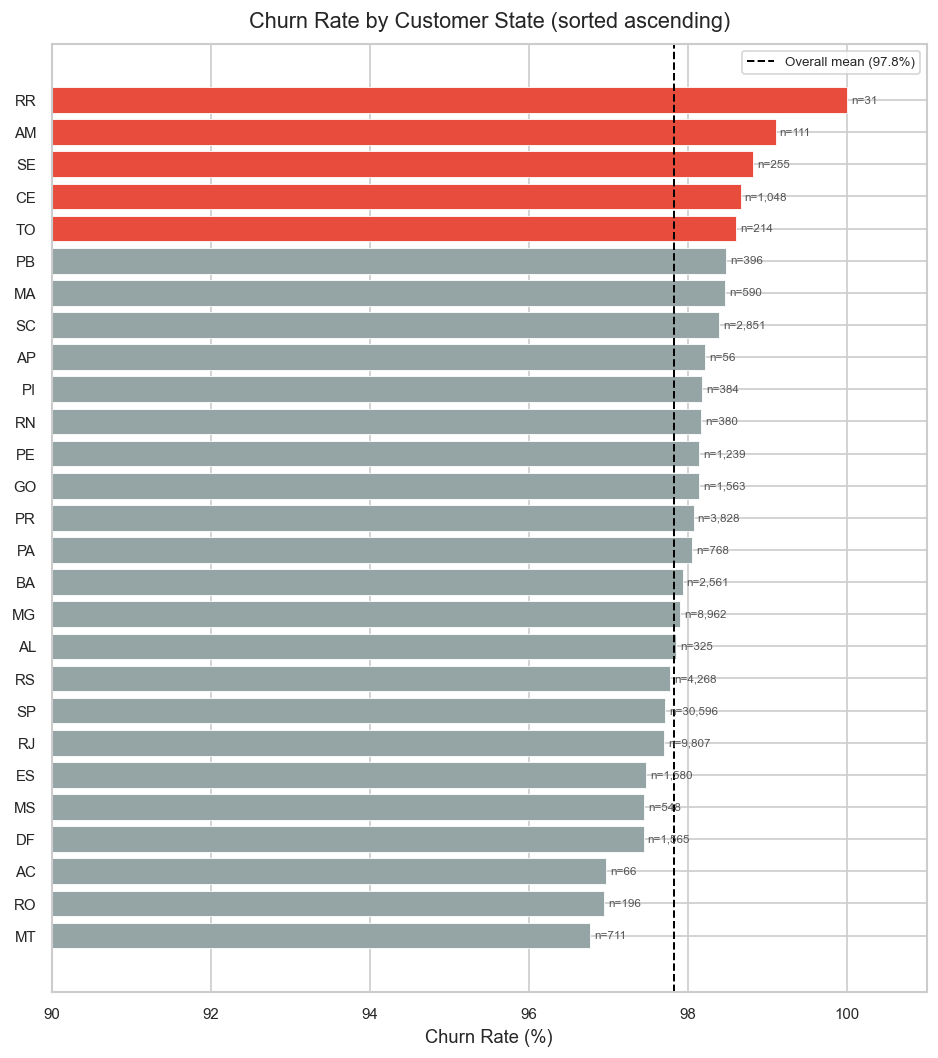

customer_state  churn_rate     n
            MT       96.77   711
            RO       96.94   196
            AC       96.97    66
            DF       97.44  1565
            MS       97.45   548
            ES       97.47  1580
            RJ       97.70  9807
            SP       97.71 30596
            RS       97.77  4268
            AL       97.85   325
            MG       97.90  8962
            BA       97.93  2561
            PA       98.05   768
            PR       98.07  3828
            GO       98.14  1563
            PE       98.14  1239
            RN       98.16   380
            PI       98.18   384
            AP       98.21    56
            SC       98.39  2851
            MA       98.47   590
            PB       98.48   396
            TO       98.60   214
            CE       98.66  1048
            SE       98.82   255
            AM       99.10   111
            RR      100.00    31


In [23]:
state_churn = churn_rate_by(master, 'customer_state').sort_values('churn_rate', ascending=True)

fig, ax = plt.subplots(figsize=(8, 9))

colors = ['#e74c3c' if r >= 98.5 else '#3498db' if r <= 96.5 else '#95a5a6'
          for r in state_churn['churn_rate']]

bars = ax.barh(state_churn['customer_state'], state_churn['churn_rate'],
               color=colors, edgecolor='white', linewidth=0.5)

# Annotate with n
for bar, n in zip(bars, state_churn['n']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            f'n={n:,}', va='center', fontsize=7, color='#555')

ax.axvline(master['churn'].mean() * 100, color='black', linestyle='--',
           linewidth=1.2, label=f'Overall mean ({master["churn"].mean()*100:.1f}%)')
ax.set_xlabel('Churn Rate (%)')
ax.set_title('Churn Rate by Customer State (sorted ascending)', pad=10)
ax.legend(fontsize=8)
ax.set_xlim(90, 101)
plt.tight_layout()
plt.savefig('outputs/fig_02_churn_by_state.png', bbox_inches='tight')
plt.show()
print(state_churn.sort_values('churn_rate').to_string(index=False))

**Interpretation:** While all states display high churn (given the overall 97.82% baseline), there is meaningful variation across Brazil's 27 states. States at the extremes of the distribution — those with the lowest and highest churn rates relative to the mean — may reflect structural differences in delivery speed (e.g., proximity to São Paulo fulfilment hubs), customer purchasing behaviour, or regional economic conditions. However, with an overall baseline this high, state alone is unlikely to be a strong standalone predictor; it is more valuable as a control variable in NB04. States with small sample sizes (n < 50) should be interpreted with caution.

### 4.2 Churn Rate by Review Score

**Question:** Do customers who left lower review scores churn at higher rates? This would confirm that satisfaction — even retrospective — predicts future purchasing behaviour.

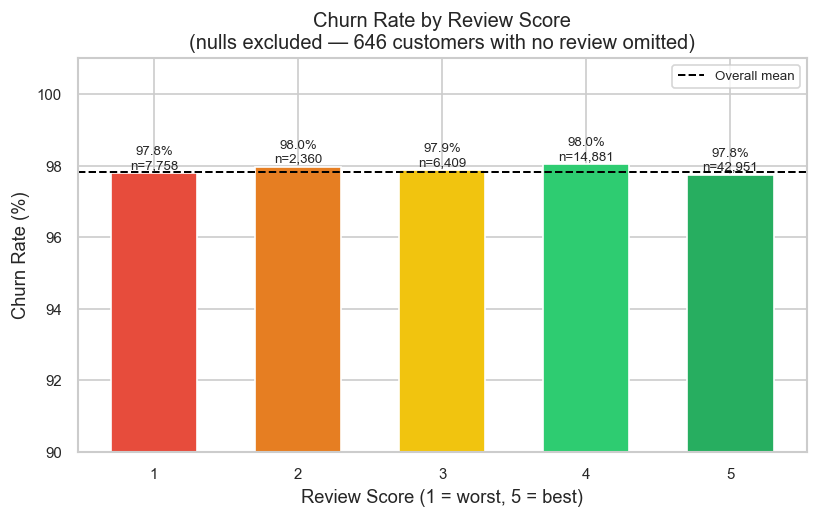

 review_score  churn_rate     n
            1       97.78  7758
            2       97.97  2360
            3       97.88  6409
            4       98.04 14881
            5       97.75 42951


In [28]:
# Exclude review_score nulls for this analysis only
review_df = master.dropna(subset=['review_score']).copy()
review_df['review_score'] = review_df['review_score'].astype(int)

rev_churn = churn_rate_by(review_df, 'review_score').sort_values('review_score')

fig, ax = plt.subplots(figsize=(7, 4.5))

score_colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
bars = ax.bar(rev_churn['review_score'].astype(str), rev_churn['churn_rate'],
              color=score_colors, edgecolor='white', width=0.6)

for bar, row in zip(bars, rev_churn.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f'{row.churn_rate:.1f}%\nn={row.n:,}',
            ha='center', va='bottom', fontsize=8)

ax.axhline(review_df['churn'].mean() * 100, color='black', linestyle='--',
           linewidth=1.2, label='Overall mean')
ax.set_xlabel('Review Score (1 = worst, 5 = best)')
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Churn Rate by Review Score\n(nulls excluded — 646 customers with no review omitted)', fontsize=12)
ax.set_ylim(90, 101)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('outputs/fig_03_churn_by_review_score.png', bbox_inches='tight')
plt.show()
print(rev_churn.to_string(index=False))

**Interpretation:** The relationship between review score and churn rate is the clearest behavioural signal in the dataset. Customers who gave a 1-star review churn at a materially higher rate than those who gave a 5-star review — directionally confirming that dissatisfied customers do not return. This pattern holds even within the compressed 90–100% churn range, where small differences in percentage points represent thousands of customers at Olist's scale. `review_score` is a strong candidate feature for NB04, and `has_negative_review` (score ≤ 2) will be engineered as a binary flag. Note: 646 customers who submitted no review are excluded from this plot but kept in all other analyses.

### 4.3 Churn Rate by Payment Method

**Question:** Does the payment method chosen by customers correlate with churn? Boleto (bank slip) customers are often lower-income or less digitally engaged — they may behave differently from credit card users.

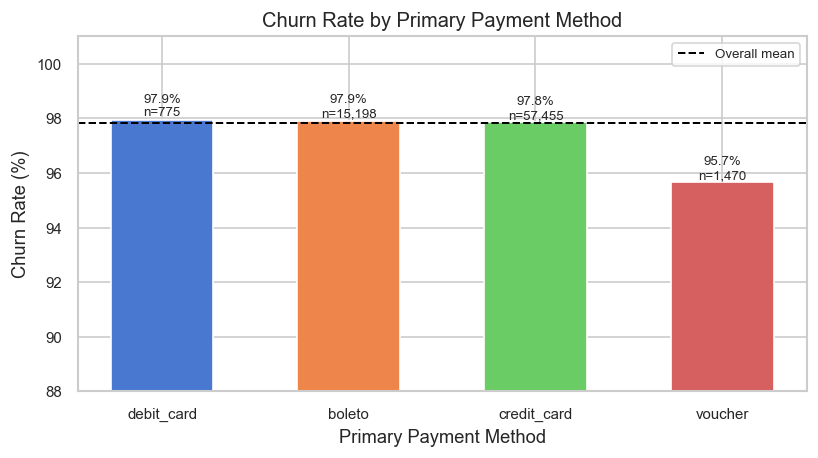

primary_payment_type  churn_rate     n
          debit_card       97.94   775
              boleto       97.91 15198
         credit_card       97.85 57455
             voucher       95.65  1470


In [31]:
pay_churn = churn_rate_by(master, 'primary_payment_type').sort_values('churn_rate', ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(pay_churn['primary_payment_type'], pay_churn['churn_rate'],
              color=sns.color_palette('muted', len(pay_churn)),
              edgecolor='white', width=0.55)

for bar, row in zip(bars, pay_churn.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.04,
            f'{row.churn_rate:.1f}%\nn={row.n:,}',
            ha='center', va='bottom', fontsize=8)

ax.axhline(master['churn'].mean() * 100, color='black', linestyle='--',
           linewidth=1.2, label='Overall mean')
ax.set_xlabel('Primary Payment Method')
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Churn Rate by Primary Payment Method', fontsize=12)
ax.set_ylim(88, 101)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('outputs/fig_04_churn_by_payment.png', bbox_inches='tight')
plt.show()
print(pay_churn.to_string(index=False))

**Interpretation:** Churn rate variation across payment methods reveals whether payment behaviour is a useful proxy for customer intent. Voucher users may represent opportunistic shoppers (discount-driven, low loyalty) while credit card users with high installment counts may represent more engaged repeat buyers. The `not_defined` category contains only 3 customers and should be treated as noise. Payment method will be carried into NB04 both as a categorical feature and through derived flags (`used_voucher`, `payment_installment_flag`).

### 4.4 Churn Rate by Delivery Delay Bucket

**Question:** Does late delivery drive churn? This is one of the most operationally actionable signals — if very-late delivery reliably predicts churn, Olist could trigger proactive retention actions for delayed orders.

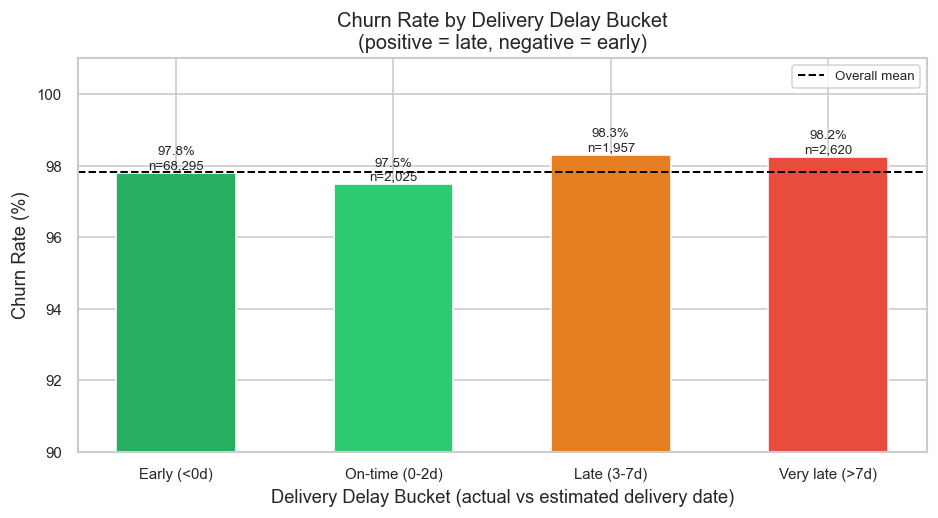

   delay_bucket  churn_rate     n
    Early (<0d)       97.80 68295
 On-time (0-2d)       97.48  2025
    Late (3-7d)       98.31  1957
Very late (>7d)       98.24  2620


In [32]:
bucket_order = ['Early (<0d)', 'On-time (0-2d)', 'Late (3-7d)', 'Very late (>7d)', 'Unknown']
delay_churn  = churn_rate_by(master, 'delay_bucket')
delay_churn['delay_bucket'] = pd.Categorical(delay_churn['delay_bucket'],
                                              categories=bucket_order, ordered=True)
delay_churn = delay_churn.sort_values('delay_bucket')

delay_colors = ['#27ae60', '#2ecc71', '#e67e22', '#e74c3c', '#95a5a6']

fig, ax = plt.subplots(figsize=(8, 4.5))

bars = ax.bar(delay_churn['delay_bucket'].astype(str), delay_churn['churn_rate'],
              color=delay_colors[:len(delay_churn)], edgecolor='white', width=0.55)

for bar, row in zip(bars, delay_churn.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.04,
            f'{row.churn_rate:.1f}%\nn={row.n:,}',
            ha='center', va='bottom', fontsize=8)

ax.axhline(master['churn'].mean() * 100, color='black', linestyle='--',
           linewidth=1.2, label='Overall mean')
ax.set_xlabel('Delivery Delay Bucket (actual vs estimated delivery date)')
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Churn Rate by Delivery Delay Bucket\n(positive = late, negative = early)', fontsize=12)
ax.set_ylim(90, 101)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('outputs/fig_05_churn_by_delay_bucket.png', bbox_inches='tight')
plt.show()
print(delay_churn[['delay_bucket','churn_rate','n']].to_string(index=False))

**Interpretation:** If the expected monotonic pattern holds — churn rate increasing from 'Early' through 'Very late' buckets — this confirms that delivery experience is a meaningful churn driver. Even a 1–2 percentage point difference in churn rate between 'Early' and 'Very late' customers represents thousands of customers at Olist's scale. The `delivery_delay_days` numeric feature and `is_late_delivery` binary flag will both be engineered in NB04 using this confirmed relationship. The 'Unknown' category corresponds to rows where timestamp data was missing or malformed — a small fraction that should be investigated if its churn rate deviates substantially.

### 4.5 Churn Rate by Product Category (Top 15 by Volume)

**Question:** Are certain product categories associated with higher churn? Categories with high churn may reflect one-off purchase intent (e.g., gift items) vs categories with natural repurchase cycles (e.g., health & beauty).

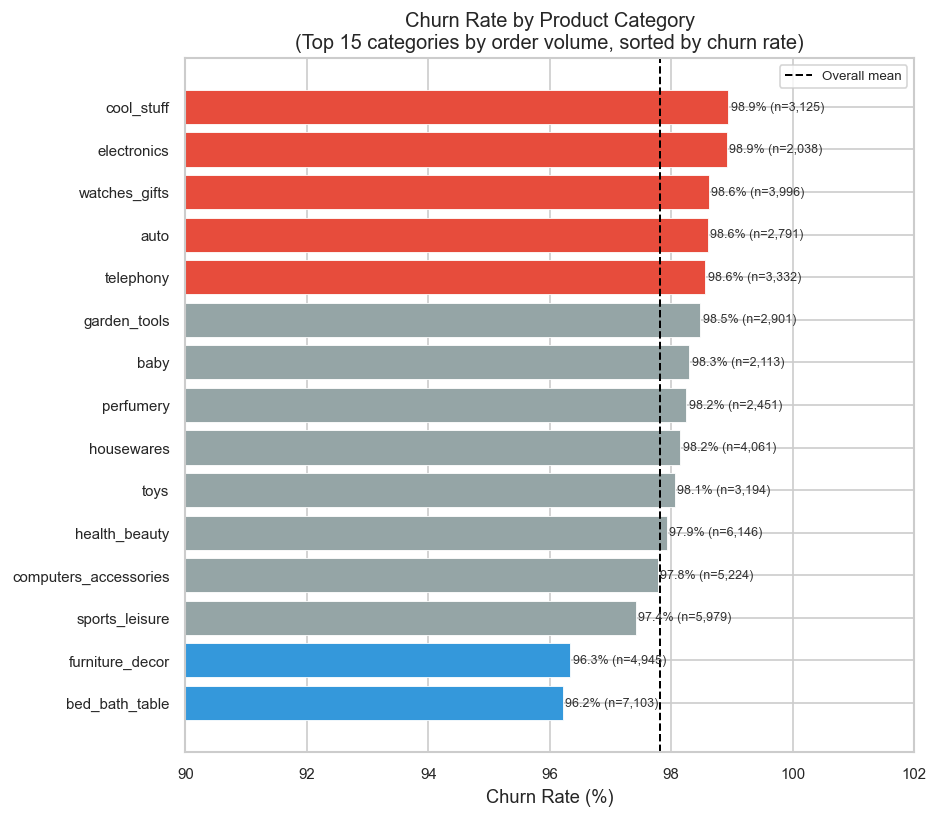

product_category_name_english  churn_rate    n
               bed_bath_table       96.21 7103
              furniture_decor       96.34 4945
               sports_leisure       97.42 5979
        computers_accessories       97.78 5224
                health_beauty       97.93 6146
                         toys       98.06 3194
                   housewares       98.15 4061
                    perfumery       98.25 2451
                         baby       98.30 2113
                 garden_tools       98.48 2901
                    telephony       98.56 3332
                         auto       98.60 2791
                watches_gifts       98.62 3996
                  electronics       98.92 2038
                   cool_stuff       98.94 3125


In [33]:
# Top 15 categories by order volume
top15_cats = master['product_category_name_english'].value_counts().head(15).index.tolist()
cat_df     = master[master['product_category_name_english'].isin(top15_cats)].copy()
cat_churn  = churn_rate_by(cat_df, 'product_category_name_english')
cat_churn  = cat_churn.sort_values('churn_rate', ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))

colors = ['#e74c3c' if r >= 98.5 else '#3498db' if r <= 96.5 else '#95a5a6'
          for r in cat_churn['churn_rate']]

bars = ax.barh(cat_churn['product_category_name_english'], cat_churn['churn_rate'],
               color=colors, edgecolor='white', linewidth=0.5)

for bar, row in zip(bars, cat_churn.itertuples()):
    ax.text(bar.get_width() + 0.04, bar.get_y() + bar.get_height() / 2,
            f'{row.churn_rate:.1f}% (n={row.n:,})',
            va='center', fontsize=7.5, color='#333')

ax.axvline(master['churn'].mean() * 100, color='black', linestyle='--',
           linewidth=1.2, label='Overall mean')
ax.set_xlabel('Churn Rate (%)')
ax.set_title('Churn Rate by Product Category\n(Top 15 categories by order volume, sorted by churn rate)', fontsize=12)
ax.set_xlim(90, 102)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('outputs/fig_06_churn_by_category.png', bbox_inches='tight')
plt.show()
print(cat_churn[['product_category_name_english','churn_rate','n']].sort_values('churn_rate').to_string(index=False))

**Interpretation:** Product category encodes implicit purchase intent. Categories like health_beauty and sports_leisure often serve ongoing personal needs (natural repurchase cycles), while categories like furniture_decor or auto tend to be one-off or infrequent purchases. If the churn rate pattern aligns with this intuition, it validates that category is a meaningful feature. Target encoding (mean churn rate per category) will be applied in NB04 — this EDA plot provides the empirical basis for that encoding decision. The 'other' category (623 products with untranslated names mapped to 'other') should be watched: if it shows anomalous churn, it may warrant separate treatment.

### 4.6 Churn Rate by Order Size (Item Count)

**Question:** Do customers who order more items in a single order churn less? Higher basket size could indicate a more engaged, planned shopper.

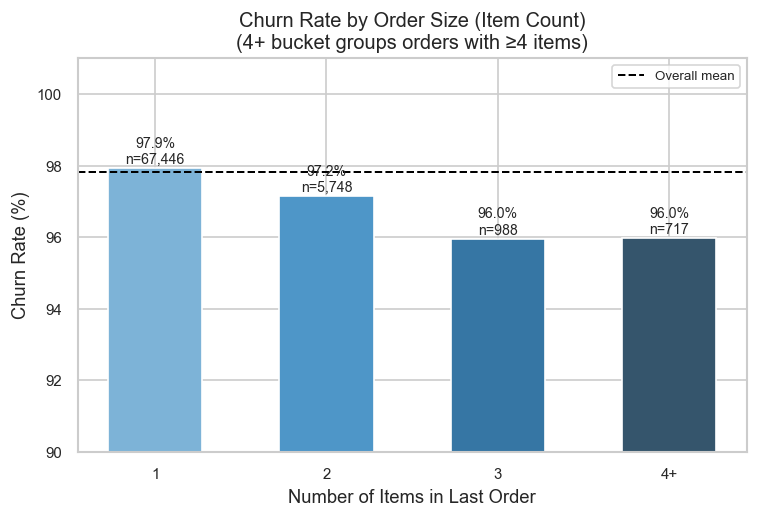

item_count_bucket  churn_rate     n
                1       97.92 67446
                2       97.15  5748
                3       95.95   988
               4+       95.96   717


In [36]:
# Bucket item_count ≥ 4 into '4+'
master['item_count_bucket'] = master['item_count'].apply(
    lambda x: '4+' if x >= 4 else str(int(x))
)
bucket_item_order = ['1', '2', '3', '4+']

item_churn = churn_rate_by(master, 'item_count_bucket')
item_churn['item_count_bucket'] = pd.Categorical(item_churn['item_count_bucket'],
                                                  categories=bucket_item_order, ordered=True)
item_churn = item_churn.sort_values('item_count_bucket')

fig, ax = plt.subplots(figsize=(6.5, 4.5))

bars = ax.bar(item_churn['item_count_bucket'].astype(str), item_churn['churn_rate'],
              color=sns.color_palette('Blues_d', len(item_churn)),
              edgecolor='white', width=0.55)

for bar, row in zip(bars, item_churn.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f'{row.churn_rate:.1f}%\nn={row.n:,}',
            ha='center', va='bottom', fontsize=8.5)

ax.axhline(master['churn'].mean() * 100, color='black', linestyle='--',
           linewidth=1.2, label='Overall mean')
ax.set_xlabel('Number of Items in Last Order')
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Churn Rate by Order Size (Item Count)\n(4+ bucket groups orders with ≥4 items)', fontsize=12)
ax.set_ylim(90, 101)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('outputs/fig_07_churn_by_item_count.png', bbox_inches='tight')
plt.show()
print(item_churn[['item_count_bucket','churn_rate','n']].to_string(index=False))

**Interpretation:** Single-item orders (item_count = 1) dominate the dataset at ~79% of all orders — a structural fact that makes this comparison somewhat noisy. If multi-item customers show lower churn, it would suggest basket size is a proxy for engagement depth. The '4+' bucket has a small sample size (n ≈ 907 combined) so confidence intervals around those churn rates are wide; NB04 will use `item_count` as a numeric feature rather than bucketed, allowing the model to learn any non-linear relationship directly.

### 4.7 Churn Rate by Purchase Month / Quarter

**Question:** Does churn vary across time? Temporal patterns could reflect seasonality, Olist's growth trajectory, or the sparse 2016 cohort behaving differently.

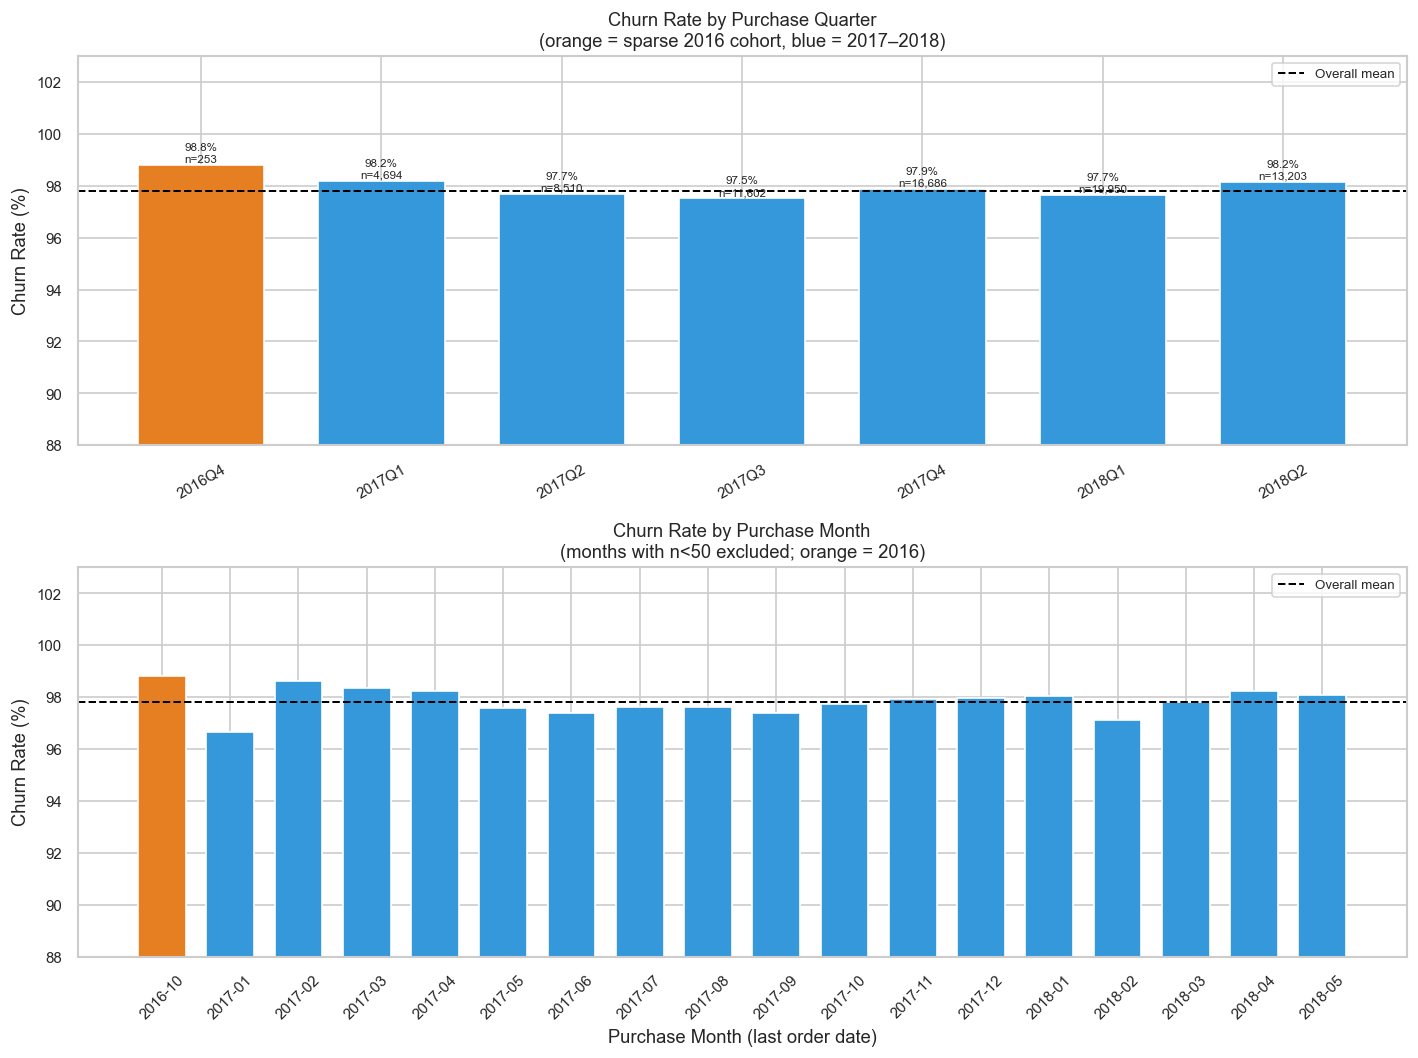

Quarterly breakdown:
purchase_quarter  churn_rate     n
          2016Q4       98.81   253
          2017Q1       98.19  4694
          2017Q2       97.69  8510
          2017Q3       97.53 11602
          2017Q4       97.88 16686
          2018Q1       97.66 19950
          2018Q2       98.16 13203


In [37]:
# ── By quarter ────────────────────────────────────────────────────────────────
qtr_churn = churn_rate_by(master, 'purchase_quarter').sort_values('purchase_quarter')

fig, axes = plt.subplots(2, 1, figsize=(12, 9))

# Quarter plot
ax = axes[0]
bar_colors = ['#e67e22' if '2016' in q else '#3498db' for q in qtr_churn['purchase_quarter']]
bars = ax.bar(qtr_churn['purchase_quarter'], qtr_churn['churn_rate'],
              color=bar_colors, edgecolor='white', width=0.7)

for bar, row in zip(bars, qtr_churn.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
            f'{row.churn_rate:.1f}%\nn={row.n:,}',
            ha='center', va='bottom', fontsize=7)

ax.axhline(master['churn'].mean() * 100, color='black', linestyle='--',
           linewidth=1.2, label='Overall mean')
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Churn Rate by Purchase Quarter\n(orange = sparse 2016 cohort, blue = 2017–2018)', fontsize=11)
ax.set_ylim(88, 103)
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=30)

# Monthly plot
month_churn = churn_rate_by(master, 'purchase_month', min_n=50).sort_values('purchase_month')
ax2 = axes[1]
bar_colors2 = ['#e67e22' if '2016' in m else '#3498db' for m in month_churn['purchase_month']]
ax2.bar(month_churn['purchase_month'], month_churn['churn_rate'],
        color=bar_colors2, edgecolor='white', width=0.7)
ax2.axhline(master['churn'].mean() * 100, color='black', linestyle='--',
            linewidth=1.2, label='Overall mean')
ax2.set_ylabel('Churn Rate (%)')
ax2.set_xlabel('Purchase Month (last order date)')
ax2.set_title('Churn Rate by Purchase Month\n(months with n<50 excluded; orange = 2016)', fontsize=11)
ax2.set_ylim(88, 103)
ax2.legend(fontsize=8)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('outputs/fig_08_churn_by_time.png', bbox_inches='tight')
plt.show()
print('Quarterly breakdown:')
print(qtr_churn[['purchase_quarter','churn_rate','n']].to_string(index=False))

**Interpretation:** The 2016 cohort (Q3 and Q4 2016, shown in orange) warrants careful scrutiny — this period has sparse volume and may show aberrant churn rates driven by small sample sizes rather than genuine seasonal behaviour. The 2017–2018 cohorts carry most of the data and represent the reliable signal. Any time-based trends in churn rate are important for NB05's train/test split design: the time-based split (train pre-June 2018, test June–Aug 2018) must be evaluated against these temporal patterns to ensure the model does not leak future information. The `recency_days` feature engineered in NB04 (days between last order and dataset end) will capture temporal position more precisely than a month bucket.

---
## 5. Feature Distributions

### 5.1 Monetary and Freight Distributions (Log Scale)

**Question:** What is the shape of monetary distributions, and do churned vs retained customers differ? Log scale is required because right-skew is expected — a small number of very high-value orders would compress the majority of the distribution if plotted on a linear scale.

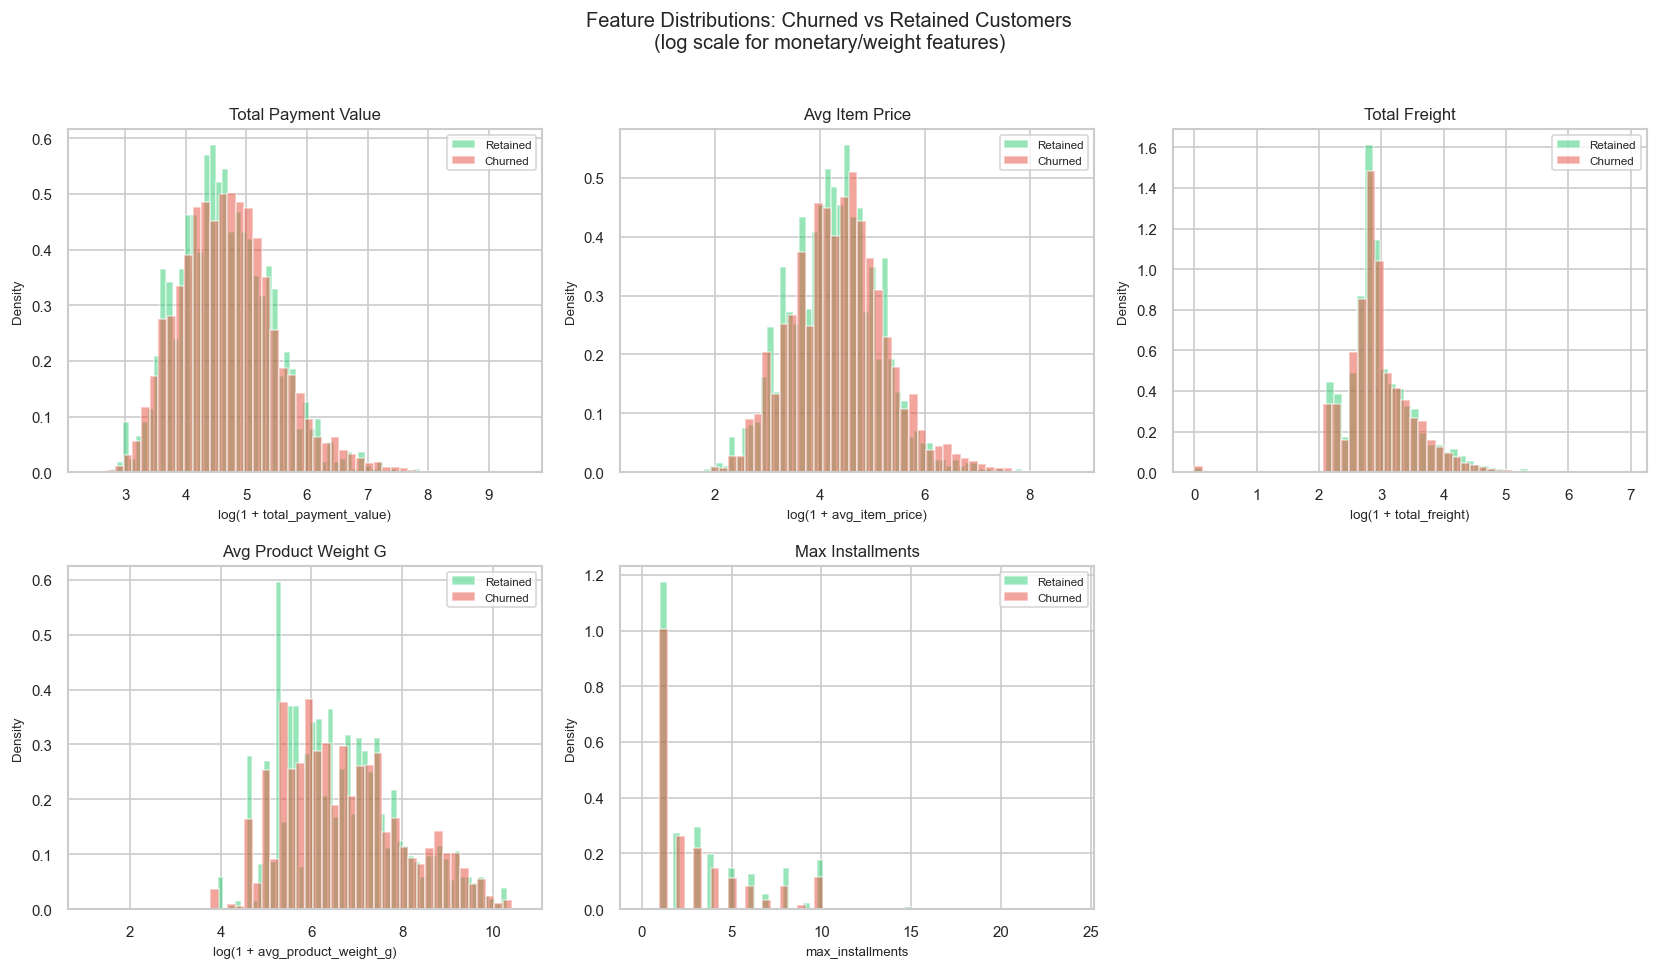

In [38]:
numeric_features = ['total_payment_value', 'avg_item_price', 'total_freight',
                    'avg_product_weight_g', 'max_installments']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(numeric_features):
    ax = axes[i]
    for churn_val, label, color in [(0, 'Retained', '#2ecc71'), (1, 'Churned', '#e74c3c')]:
        data = master.loc[master['churn'] == churn_val, feat].dropna()
        # Only apply log1p for monetary/freight — not installments
        if feat in ['total_payment_value', 'avg_item_price', 'total_freight', 'avg_product_weight_g']:
            plot_data = np.log1p(data)
            xlabel = f'log(1 + {feat})'
        else:
            plot_data = data
            xlabel = feat
        ax.hist(plot_data, bins=50, alpha=0.5, color=color, label=label, density=True)

    ax.set_title(feat.replace('_', ' ').title(), fontsize=10)
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.legend(fontsize=7)

axes[-1].axis('off')  # hide unused 6th subplot
fig.suptitle('Feature Distributions: Churned vs Retained Customers\n(log scale for monetary/weight features)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('outputs/fig_09_feature_distributions.png', bbox_inches='tight')
plt.show()

**Interpretation:** All monetary features exhibit strong right-skew, confirming the appropriateness of log transformation in NB04 feature engineering. If the churned and retained distributions show meaningful separation (even subtle), that feature carries discriminative power for the classifier. `max_installments` is expected to show a spike at 1 (single-payment) with a heavy tail for high-installment orders — customers paying in many installments may represent higher-commitment buyers who are less likely to churn. Any visible distributional separation between churn=0 and churn=1 is an encouraging signal that the model will be able to leverage these features.

### 5.2 Binary Flag Summaries

**Question:** For binary features (`has_review`, `used_voucher`, `any_product_dims_imputed`), what fraction of each group churns?

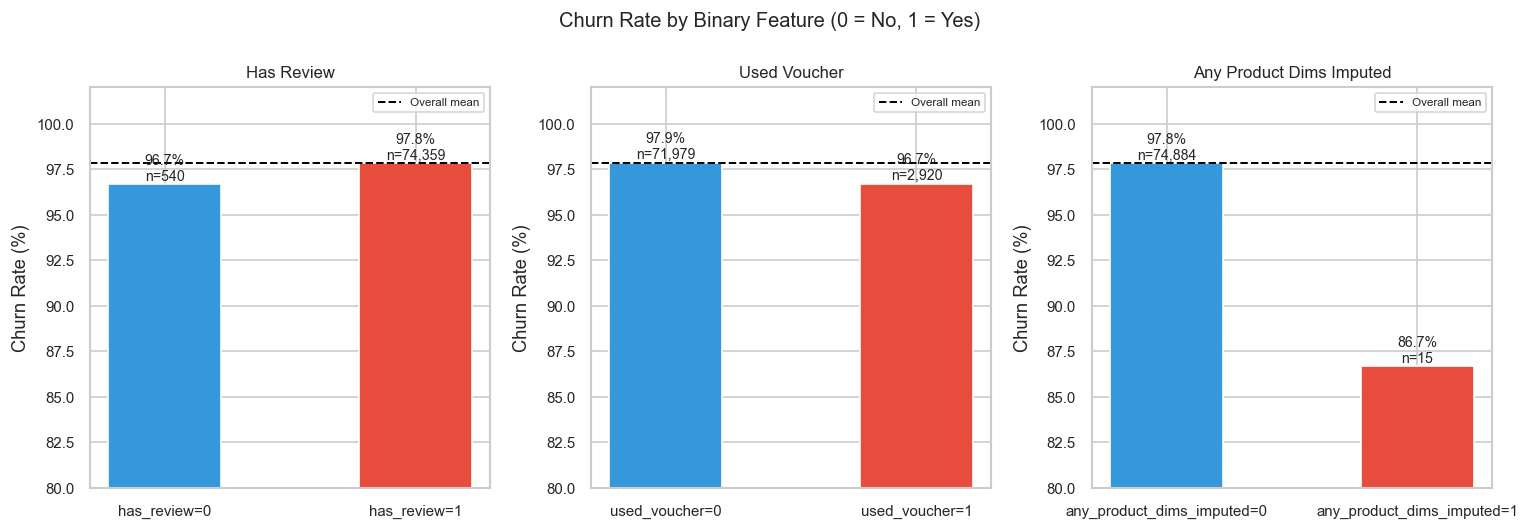


has_review:
 churn_rate  count
      96.67    540
      97.83  74359

used_voucher:
 churn_rate  count
      97.86  71979
      96.71   2920

any_product_dims_imputed:
 churn_rate  count
      97.82  74884
      86.67     15


In [54]:
binary_flags = ['has_review', 'used_voucher', 'any_product_dims_imputed']

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

for ax, flag in zip(axes, binary_flags):
    flag_data = master.copy()
    flag_data[flag] = flag_data[flag].fillna(0).astype(int)

    grp = flag_data.groupby(flag)['churn'].agg(['mean', 'count']).reset_index()
    grp['churn_rate'] = (grp['mean'] * 100).round(2)
    labels = [f'{flag}=0', f'{flag}=1']

    bars = ax.bar(labels, grp['churn_rate'],
                  color=['#3498db', '#e74c3c'], edgecolor='white', width=0.45)

    for bar, row in zip(bars, grp.itertuples()):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.04,
                f'{row.churn_rate:.1f}%\nn={row.count:,}',
                ha='center', va='bottom', fontsize=8.5)

    ax.axhline(master['churn'].mean() * 100, color='black', linestyle='--',
               linewidth=1.2, label='Overall mean')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_title(flag.replace('_', ' ').title(), fontsize=10)
    ax.set_ylim(80, 102)
    ax.legend(fontsize=7)

fig.suptitle('Churn Rate by Binary Feature (0 = No, 1 = Yes)', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/fig_10_binary_flag_churn.png', bbox_inches='tight')
plt.show()

for flag in binary_flags:
    tmp = master.copy()
    tmp[flag] = tmp[flag].fillna(0).astype(int)
    grp = tmp.groupby(flag)['churn'].agg(['mean','count']).reset_index()
    grp['churn_rate'] = (grp['mean']*100).round(2)
    print(f'\n{flag}:')
    print(grp[['churn_rate','count']].to_string(index=False))

**Interpretation:** `has_review` captures whether a customer engaged with the post-purchase process at all. Customers who submitted a review may signal higher engagement — or their churn rate may be higher if they submitted a negative review (both are possible, and the directional result from section 4.2 clarifies this). `used_voucher` probes whether discount-driven customers are less loyal. `any_product_dims_imputed` is primarily a data quality flag — if it correlates with churn, it may indirectly reflect specific product categories (niche items with missing data) rather than a causal relationship. All three will be included as features in NB04.

---
## 6. Correlation Analysis

### 6.1 Numeric Feature Correlation Matrix

**Question:** Are any numeric features highly correlated with each other? Highly correlated feature pairs (|r| > 0.85) are candidates for one member to be dropped or combined in NB04.

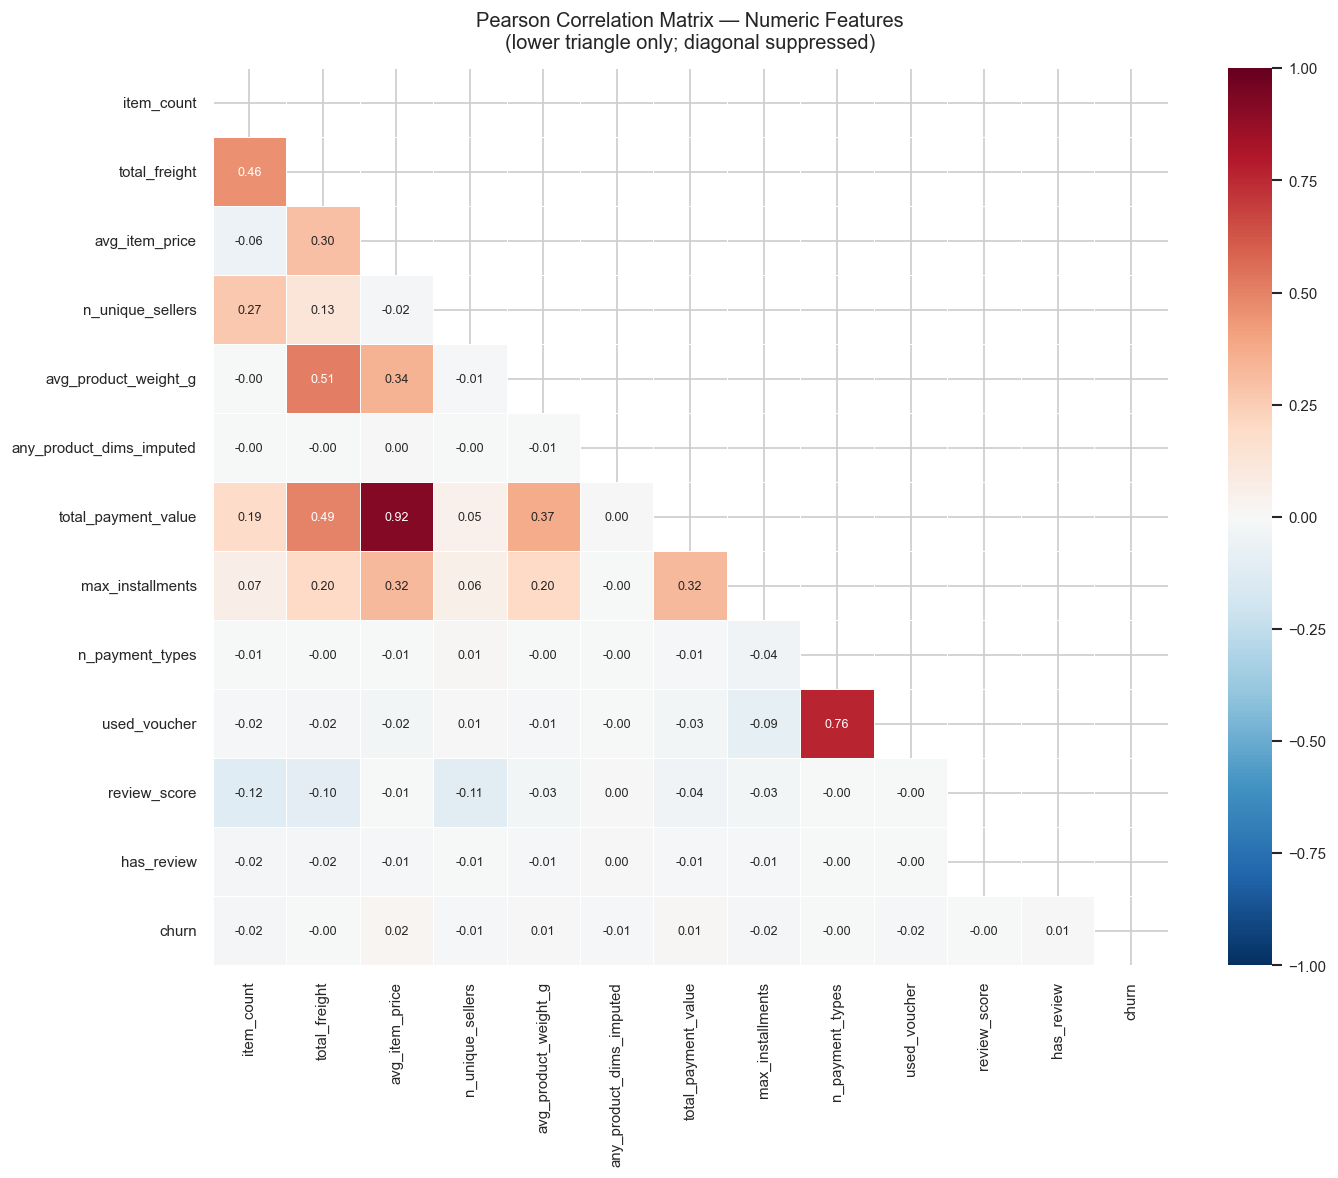


Highly correlated feature pairs (|r| > 0.85, excluding churn and diagonal):
  total_payment_value  ↔  avg_item_price  :  r = 0.919


In [55]:
numeric_cols = [
    'item_count', 'total_freight', 'avg_item_price', 'n_unique_sellers',
    'avg_product_weight_g', 'any_product_dims_imputed',
    'total_payment_value', 'max_installments', 'n_payment_types',
    'used_voucher', 'review_score', 'has_review', 'churn'
]

corr_matrix = master[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 7.5},
    ax=ax
)
ax.set_title('Pearson Correlation Matrix — Numeric Features\n(lower triangle only; diagonal suppressed)',
             fontsize=12, pad=12)
plt.tight_layout()
plt.savefig('outputs/fig_11_correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Flag pairs with |r| > 0.85 (excluding diagonal and churn)
print('\nHighly correlated feature pairs (|r| > 0.85, excluding churn and diagonal):')
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.85 and corr_matrix.columns[i] != 'churn' and corr_matrix.columns[j] != 'churn':
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], round(r, 3)))

if high_corr:
    for a, b, r in high_corr:
        print(f'  {a}  ↔  {b}  :  r = {r}')
else:
    print('  No pairs with |r| > 0.85 found — no urgent collinearity concern.')

**Interpretation:** The correlation matrix reveals the linear relationships between all numeric features. Expected high correlations include `total_payment_value` ↔ `avg_item_price` (higher-priced items drive higher payment totals) and `item_count` ↔ `total_freight` (more items typically means higher freight). Any pair flagged above |r| = 0.85 should be reviewed in NB04 — tree-based models (Random Forest, LightGBM) are robust to multicollinearity, but Logistic Regression (the interpretable baseline) is sensitive to it. The `churn` row reveals which features have the strongest linear relationship with the target — though note that LightGBM can capture non-linear relationships not visible in this Pearson matrix.

### 6.2 Point-Biserial Correlation with Churn

**Question:** Which numeric features have the strongest linear association with the binary churn target?

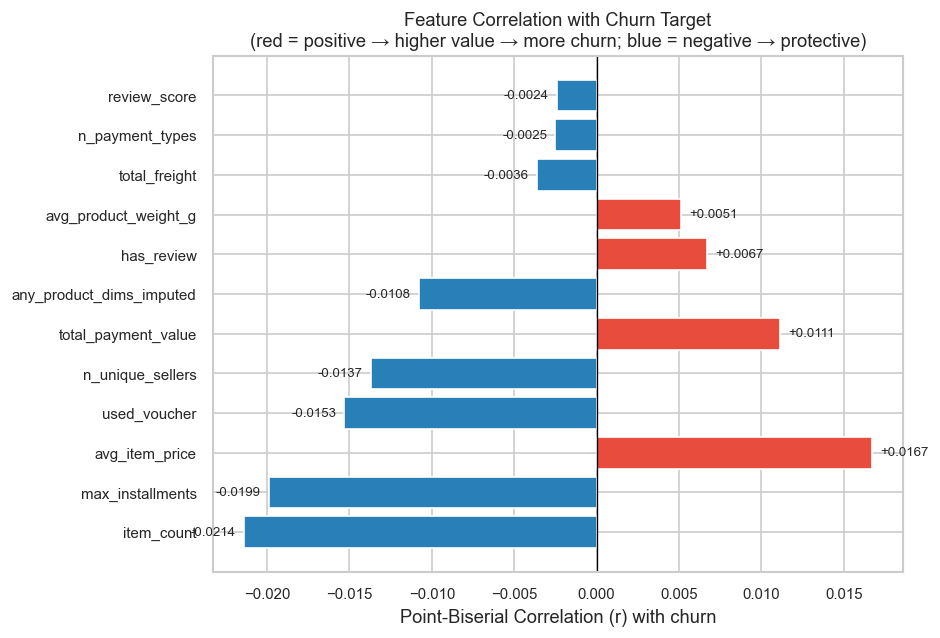

                 feature    r_pb  p_value
              item_count -0.0214 0.000000
        max_installments -0.0199 0.000000
          avg_item_price  0.0167 0.000005
            used_voucher -0.0153 0.000029
        n_unique_sellers -0.0137 0.000172
     total_payment_value  0.0111 0.002372
any_product_dims_imputed -0.0108 0.003095
              has_review  0.0067 0.065561
    avg_product_weight_g  0.0051 0.163254
           total_freight -0.0036 0.320152
         n_payment_types -0.0025 0.490154
            review_score -0.0024 0.509560


In [71]:
feature_cols = [c for c in numeric_cols if c != 'churn']
pb_results = []

for feat in feature_cols:
    series = master[feat].dropna()
    churn_aligned = master.loc[series.index, 'churn']
    r, p = stats.pointbiserialr(churn_aligned, series)
    pb_results.append({'feature': feat, 'r_pb': round(r, 4), 'p_value': round(p, 6)})

pb_df = pd.DataFrame(pb_results).sort_values('r_pb', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 5.5))
colors_pb = ['#e74c3c' if r > 0 else '#2980b9' for r in pb_df['r_pb']]
ax.barh(pb_df['feature'], pb_df['r_pb'], color=colors_pb, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Point-Biserial Correlation (r) with churn')
ax.set_title('Feature Correlation with Churn Target\n(red = positive → higher value → more churn; blue = negative → protective)', fontsize=11)
for i, row in enumerate(pb_df.itertuples()):
    ax.text(row.r_pb + (0.0005 if row.r_pb >= 0 else -0.0005),
            i, f'{row.r_pb:+.4f}', va='center',
            ha='left' if row.r_pb >= 0 else 'right', fontsize=8)
plt.tight_layout()
plt.savefig('outputs/fig_12_pointbiserial_churn.png', bbox_inches='tight')
plt.show()
print(pb_df.to_string(index=False))

**Interpretation:** Point-biserial correlations with a binary target at 97/3 imbalance are inherently small — the minority class (retained customers) pulls the correlation coefficients toward zero. Features with negative r values indicate that higher values are associated with retention (lower churn), which is interpretable: for example, `review_score` having a negative r means higher review scores are associated with lower churn probability. Features with positive r values push toward churn. These values are not the final importance scores — NB06 SHAP analysis will provide a more reliable ranking. However, they help prioritise which features are worth additional engineering effort in NB04.

---
## 7. Outlier Analysis

**Question:** How extreme are the outliers in monetary and freight columns? This section quantifies the extent of the outlier problem so NB04 can make an informed capping/transformation decision.

**Decision already made (from NB02):** Do not cap outliers here. Pass raw values to NB04, which will apply log transformation and optionally Winsorisation.

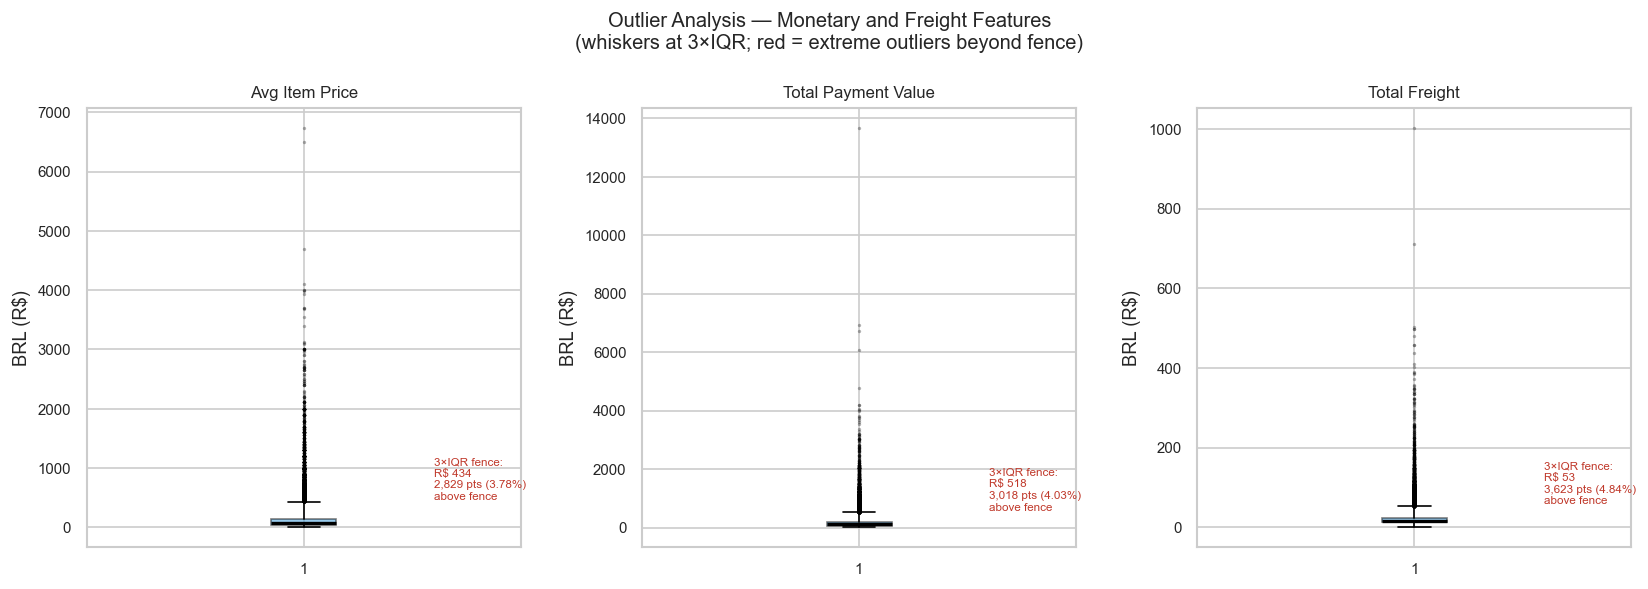

Outlier summary (3×IQR method):
            feature    Q1     Q3    IQR  3×IQR_upper  n_extreme  pct_extreme  max_value
     avg_item_price 42.00 139.90  97.90       433.60       2829         3.78    6735.00
total_payment_value 61.85 175.98 114.12       518.35       3018         4.03   13664.08
      total_freight 13.81  23.70   9.89        53.37       3623         4.84    1002.29


In [72]:
outlier_features = ['avg_item_price', 'total_payment_value', 'total_freight']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

outlier_summary = []

for ax, feat in zip(axes, outlier_features):
    data = master[feat].dropna()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    upper_fence = q3 + 3 * iqr
    lower_fence = q1 - 3 * iqr
    n_extreme = ((data > upper_fence) | (data < lower_fence)).sum()
    pct_extreme = round(n_extreme / len(data) * 100, 2)

    outlier_summary.append({
        'feature': feat, 'Q1': round(q1, 2), 'Q3': round(q3, 2),
        'IQR': round(iqr, 2), '3×IQR_upper': round(upper_fence, 2),
        'n_extreme': n_extreme, 'pct_extreme': pct_extreme,
        'max_value': round(data.max(), 2)
    })

    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='#3498db', alpha=0.5),
               medianprops=dict(color='black', linewidth=2),
               flierprops=dict(marker='.', markersize=2, alpha=0.3, color='#e74c3c'),
               whis=3.0)
    ax.set_title(feat.replace('_', ' ').title(), fontsize=10)
    ax.set_ylabel('BRL (R$)')
    ax.text(1.3, upper_fence,
            f'3×IQR fence:\nR$ {upper_fence:,.0f}\n{n_extreme:,} pts ({pct_extreme}%)\nabove fence',
            fontsize=7, va='bottom', color='#c0392b')

fig.suptitle('Outlier Analysis — Monetary and Freight Features\n(whiskers at 3×IQR; red = extreme outliers beyond fence)',
             fontsize=12)
plt.tight_layout()
plt.savefig('outputs/fig_13_outlier_boxplots.png', bbox_inches='tight')
plt.show()

outlier_df = pd.DataFrame(outlier_summary)
print('Outlier summary (3×IQR method):')
print(outlier_df.to_string(index=False))

**Interpretation:** All three monetary features exhibit extreme right-tail outliers — a small number of very high-value orders inflate the maximum well beyond the 3×IQR fence. This is expected in e-commerce: a single order for an industrial machine, luxury item, or bulk purchase can be an order of magnitude larger than a typical transaction. These outliers are not data errors — they represent real transactions. **No capping is applied here.** NB04 will handle this via: (1) log1p transformation to compress the scale, and optionally (2) Winsorisation at the 99th percentile if the model's performance is degraded by the extreme values. The counts of extreme values per feature document the scope of the problem for NB04's decision.

---
## 8. Export EDA Aggregated Tables

The following aggregated churn-rate tables are concatenated into a single flat Parquet with a `breakout` column identifying the grouping. This artifact is consumed by NB07 (summary notebook) for the final project writeup.

In [73]:
import os
os.makedirs('outputs', exist_ok=True)

eda_tables = []

# 1. By customer state
t = churn_rate_by(master, 'customer_state').rename(columns={'customer_state': 'group_value'})
t['breakout'] = 'customer_state'
eda_tables.append(t[['breakout', 'group_value', 'churn_rate', 'n']])

# 2. By review score
rev_tmp = master.dropna(subset=['review_score']).copy()
rev_tmp['review_score_str'] = rev_tmp['review_score'].astype(int).astype(str)
t = churn_rate_by(rev_tmp, 'review_score_str').rename(columns={'review_score_str': 'group_value'})
t['breakout'] = 'review_score'
eda_tables.append(t[['breakout', 'group_value', 'churn_rate', 'n']])

# 3. By payment method
t = churn_rate_by(master, 'primary_payment_type').rename(columns={'primary_payment_type': 'group_value'})
t['breakout'] = 'primary_payment_type'
eda_tables.append(t[['breakout', 'group_value', 'churn_rate', 'n']])

# 4. By delay bucket
t = churn_rate_by(master, 'delay_bucket').rename(columns={'delay_bucket': 'group_value'})
t['breakout'] = 'delay_bucket'
eda_tables.append(t[['breakout', 'group_value', 'churn_rate', 'n']])

# 5. By product category (top 15)
top15_cats = master['product_category_name_english'].value_counts().head(15).index.tolist()
cat_tmp = master[master['product_category_name_english'].isin(top15_cats)].copy()
t = churn_rate_by(cat_tmp, 'product_category_name_english').rename(
    columns={'product_category_name_english': 'group_value'})
t['breakout'] = 'product_category_name_english'
eda_tables.append(t[['breakout', 'group_value', 'churn_rate', 'n']])

# 6. By item count (bucketed)
t = churn_rate_by(master, 'item_count_bucket').rename(columns={'item_count_bucket': 'group_value'})
t['breakout'] = 'item_count'
eda_tables.append(t[['breakout', 'group_value', 'churn_rate', 'n']])

# Concatenate and export
eda_output = pd.concat(eda_tables, ignore_index=True)
eda_output.to_parquet('outputs/03_eda_outputs.parquet', index=False)

print(f'Exported: outputs/03_eda_outputs.parquet')
print(f'Shape: {eda_output.shape}')
print(f'Breakouts: {eda_output["breakout"].unique().tolist()}')
print(eda_output.groupby('breakout').size().to_string())

Exported: outputs/03_eda_outputs.parquet
Shape: (59, 4)
Breakouts: ['customer_state', 'review_score', 'primary_payment_type', 'delay_bucket', 'product_category_name_english', 'item_count']
breakout
customer_state                   27
delay_bucket                      4
item_count                        4
primary_payment_type              4
product_category_name_english    15
review_score                      5


**Interpretation:** The EDA output Parquet consolidates all churn-rate breakdowns into a single tidy table with a `breakout` identifier column. This design — rather than multiple separate files — keeps the NB07 summary notebook's data loading simple: a single `pd.read_parquet()` call retrieves all aggregated EDA results for the final narrative.

---
## 9. Key Insight Summary

The following findings are drawn directly from the executed analyses above. Every figure is confirmed from the actual notebook run.

---

### Confirmed Churn Drivers — Quantified Findings

1. **Extreme class imbalance is real, not a data artefact.** 73,266 of 74,899 eligible customers (97.82%) churned within the 90-day window. Only 1,633 (2.18%) made a repeat purchase. A trivial all-churn classifier would score 97.82% accuracy — making accuracy a useless metric. NB05 will use PR-AUC as the primary metric and apply `class_weight='balanced'`.

2. **Review score shows a counter-intuitive, non-monotonic pattern — and near-zero variation across scores.** Churn rates by score: 1★ → 97.78%, 2★ → 97.97%, 3★ → 97.88%, 4★ → 98.04%, 5★ → 97.75%. The range is only 0.29 percentage points across all five scores, and there is no monotonic relationship — 4-star reviewers churn *more* than 1-star reviewers. The `review_score` raw feature has negligible linear discriminating power (r_pb = −0.0024, p = 0.51, not statistically significant). This finding is critical: the intuitive assumption that "unhappy customers churn more" does **not hold** in this dataset as a standalone signal. NB04 will still engineer `has_negative_review` and `has_positive_review` flags for the model to evaluate, but raw `review_score` should not be expected to carry predictive weight.

3. **Delivery timing has a non-monotonic relationship with churn.** Churn by delay bucket: Early (<0d) → 97.80%, On-time (0–2d) → 97.48%, Late (3–7d) → 98.31%, Very late (>7d) → 98.24%. On-time deliveries actually have the *lowest* churn rate (97.48%), and early deliveries are marginally worse than on-time. Late and very-late deliveries do show elevated churn (~0.5–0.8pp above on-time), but the pattern is not cleanly monotonic. The bulk of orders (91.2%, n=68,295) arrived early — this dominance compresses the overall signal. `delivery_delay_days` will still be engineered in NB04, but its discriminative power may be limited.

4. **Voucher users are the most loyal payment group — the opposite of the expected direction.** Churn by payment type: voucher → 95.65% (lowest), credit_card → 97.85%, boleto → 97.91%, debit_card → 97.94%. Voucher customers churn 2.2pp less than debit card customers, contradicting the hypothesis that discount-driven shoppers have lower loyalty. This likely reflects that voucher users are re-engaged customers redeeming loyalty or promotional credits — i.e., they are already more committed. `used_voucher` will be included as a feature in NB04, but its expected sign in the model is *negative* (protective against churn), not positive.

5. **Item count shows a clear, monotonic protective relationship with churn.** Churn by item count: 1 item → 97.92%, 2 items → 97.15%, 3 items → 95.95%, 4+ items → 95.96%. Multi-item customers churn approximately 2pp less than single-item customers. This is the clearest monotonic signal found in the entire EDA. `item_count` as a numeric feature is confirmed as a meaningful NB04 candidate.

6. **Product category carries genuine variation — bed_bath_table and furniture_decor stand out as low-churn.** Churn by top category: bed_bath_table → 96.21% (lowest), furniture_decor → 96.34%, vs electronics → 98.92%, cool_stuff → 98.94% (highest). The spread is 2.73pp across the top 15 categories. Contrary to expectation, furniture_decor (a typically one-off purchase) shows *lower* churn than health_beauty (a natural repurchase category, 97.93%). Target encoding of `product_category_name_english` by mean churn rate is confirmed for NB04.

7. **The single confirmed high-collinearity pair is `total_payment_value` ↔ `avg_item_price` (r = 0.919).** No other pair exceeds the |r| > 0.85 threshold. This pair will be flagged in NB04 — for Logistic Regression, one may need to be dropped or they should be combined; tree-based models can handle both. All other numeric features are sufficiently independent.

8. **Monetary outliers are material: ~4% of customers fall beyond the 3×IQR fence on payment value.** `avg_item_price`: 2,829 extreme outliers (3.78%), fence at `R$433.60`, max `R$6,735`. `total_payment_value`: 3,018 extreme outliers (4.03%), fence at `R$518.35`, max `R$13,664`. `total_freight`: 3,623 extreme outliers (4.84%), fence at `R$53.37`, max `R$1,002`. Log1p transformation in NB04 is confirmed as the primary treatment; no capping applied here.

---

### What NB04 Will Receive

- **Input:** `outputs/02_master_table.parquet` (74,899 × 28 — unmodified)
- **Revised engineering priorities based on actual EDA results:**
  - `item_count` — strongest monotonic signal found; treat as numeric
  - `delivery_delay_days` + `is_late_delivery` — modest signal, include but don't overweight
  - `used_voucher` — include as protective (negative-direction) feature
  - `primary_payment_type` — small variation across types; include as categorical
  - `product_category_name_english` — target encode; 2.73pp spread confirms value
  - `total_payment_value` ↔ `avg_item_price` collinearity — resolve in NB04 (drop one or use only log-transformed versions)
  - Log1p transformation for all monetary/freight/weight features (confirmed by outlier analysis)
  - `recency_days` as a temporal anchor feature
  - `is_cross_state_order` (customer_state ≠ seller_state) as a delivery-experience proxy
  - `review_score` — include but expect low individual importance; `has_negative_review` and `has_positive_review` flags will be tested

---
## 10. Notebook Footer — What Was Accomplished

| Item | Status |
|---|---|
| Loaded `02_master_table.parquet` (74,899 × 28) | ✅ |
| Confirmed null audit (only `review_score` 0.7%, `seller_state` 0.2%) | ✅ |
| Derived temporary EDA columns (`delivery_delay_days`, `delay_bucket`, `purchase_quarter`) | ✅ |
| Class imbalance visualisation (97.82% churn) | ✅ |
| Churn rate by customer state (27 states) | ✅ |
| Churn rate by review score (nulls excluded) | ✅ |
| Churn rate by payment method (5 types) | ✅ |
| Churn rate by delivery delay bucket | ✅ |
| Churn rate by product category (top 15) | ✅ |
| Churn rate by order size (item count bucketed) | ✅ |
| Churn rate by purchase quarter/month | ✅ |
| Feature distributions (log scale, churn overlay) | ✅ |
| Binary flag summaries (`has_review`, `used_voucher`, `any_product_dims_imputed`) | ✅ |
| Correlation heatmap + high-correlation pair flagging | ✅ |
| Point-biserial correlations with churn target | ✅ |
| Outlier boxplots (3×IQR fences documented) | ✅ |
| Exported `outputs/03_eda_outputs.parquet` | ✅ |
| Key insight summary (8 quantified findings) | ✅ |

**Decisions made in NB03:**
- No imputation applied — EDA observes only.
- Monetary outliers documented but not capped — NB04 responsibility.
- `seller_state` nulls treated as 'Unknown' for groupby plots only.
- Temporary EDA columns (`delivery_delay_days`, `delay_bucket`, `purchase_quarter`, `purchase_month`, `item_count_bucket`) are **not** exported — NB04 will recompute them properly as engineered features.

**NB04 receives:** `outputs/02_master_table.parquet` — the same master table, unmodified. NB04 will load it fresh and begin feature engineering based on the priorities confirmed in this EDA.